# Getting Started with FAO OpenEO

This tutorial walks you through connecting to the FAO OpenEO backend, authenticating, discovering available data collections, and running your first analysis.

**What you will learn:**
- How to connect to the FAO OpenEO backend using the Python client
- How to authenticate via OIDC (FAO Single Sign-On)
- How to browse available data collections and processes
- How to load a data cube and download a result

**Prerequisites:**
- Python 3.9+
- `openeo` Python package (`pip install openeo`)
- `matplotlib` for visualization (`pip install matplotlib`)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/un-fao/openeo-docs/blob/main/tutorials/01_getting_started.ipynb)

## 1. Install Dependencies

If you haven't installed the required packages yet, uncomment and run the cell below.

In [ ]:
# !pip install openeo matplotlib rasterio

## 2. Connect to the FAO OpenEO Backend

The FAO OpenEO backend is available at `https://data.fao.org/openeo`. We use the `openeo` Python client to establish a connection.

In [1]:
import openeo

# Connect to the FAO OpenEO backend
connection = openeo.connect("https://data.fao.org/openeo")

print(f"Connected to: {connection.root_url}")
print(f"API version: {connection.capabilities().api_version()}")

Connected to: https://data.fao.org/openeo/
API version: 1.2.0


## 3. Authenticate

The FAO backend supports two authentication methods:

1. **OpenID Connect (OIDC)** — via FAO's Single Sign-On (recommended)
2. **Basic Authentication** — username and password (for programmatic access)

We'll use OIDC, which opens a browser window for you to log in with your FAO credentials.

In [2]:
# Authenticate via OIDC — this will open a browser window for FAO SSO login
connection.authenticate_oidc(provider_id="keycloak")

# Verify authentication
user_info = connection.describe_account()
print(f"Logged in as: {user_info}")

Authenticated using refresh token.
Logged in as: {'user_id': '477503ea-c49c-4b26-bc2e-07529b743f05', 'name': 'Abdallah Hadid', 'default_plan': None, 'storage': {'free': 107374182400, 'quota': 107374182400}, 'budget': None, 'links': []}


> **Note:** For programmatic access (e.g. in scripts or CI), you can use basic authentication instead:
> ```python
> connection.authenticate_basic("your_username", "your_password")
> ```

## 4. Explore Available Collections

Collections are datasets available for analysis. The FAO backend provides access to various Earth observation and derived products through the FAO STAC catalog.

In [3]:
# List all available collections
collections = connection.list_collections()

print(f"Found {len(collections)} collections:\n")
for col in collections:
    col_id = col.get("id", "N/A")
    title = col.get("title", "No title")
    print(f"  {col_id:30s} — {title}")

Found 2018 collections:

  A-PROD                         — Animal products (Global - 2015) - GLEAM3
  AC-I-2025                      — Adaptive capacity risk component (Global) - CRTB
  AC-I-CUMULATIVE-2025           — Adaptive capacity risk component cumulative (Global) - CRTB
  AEZ33                          — AEZ classification by climate, soil, terrain, land cover (Global - ~10 km - 33 classes) - GAEZ v5
  AEZ33-1KM                      — AEZ classification by climate, soil, terrain, land cover (Global - ~1 km - 33 classes) - GAEZ v5
  AEZ57                          — AEZ classification by climate, soil, terrain, land cover (Global - ~1 km - 57 classes) - GAEZ v5
  AFG-CL-CHANGE                  — Cropland area change (Afghanistan, 2018-2024 - 10 m)
  AFG-ET                         — Evapotranspiration change (Afghanistan, 2018 - 2025 - 250m)
  AFG-FLOOD-HAZ-DEPTH            — River flood hazard depth (Afghanistan, Return Period 10, 20, 50 & 100 yrs - 90 m)
  AFG-GWC              

### Inspect a Specific Collection

Let's look at the **VCI-D** (Vegetation Condition Index - Dekadal) collection in more detail.

In [4]:
# Get detailed metadata for a specific collection
collection_id = "fao-gismgr:ASIS:raster:mapsets:VCI-D"
collection_info = connection.describe_collection(collection_id)

print(f"Collection: {collection_info.get('id')}")
print(f"Title: {collection_info.get('title', 'N/A')}")
print(f"Description: {collection_info.get('description', 'N/A')[:200]}")

# Spatial extent
extent = collection_info.get("extent", {})
spatial = extent.get("spatial", {}).get("bbox", [[]])[0]
print(f"\nSpatial extent (bbox): {spatial}")

# Temporal extent
temporal = extent.get("temporal", {}).get("interval", [[]])[0]
print(f"Temporal extent: {temporal}")

Collection: fao-gismgr:ASIS:raster:mapsets:VCI-D
Title: Vegetation condition index near real time (Global - Dekadal - 1 km) - FAO ASIS
Description: The Vegetation Condition Index (VCI) evaluates the current vegetation health in comparison to the historical trends. The VCI relates current dekadal Normalized Difference Vegetation Index (NDVI) to it

Spatial extent (bbox): [-180.0, -56.00446430667499, 179.99553577188502, 75.004464285715]
Temporal extent: ['1984-01-01T00:00:00Z', '2026-08-20T00:00:00Z']


## 5. Explore Available Processes

Processes are the operations you can apply to data cubes. The FAO backend provides standard OpenEO processes plus custom FAO-specific ones.

In [5]:
# List all available processes
processes = connection.list_processes()

print(f"Found {len(processes)} processes:\n")

# Group by category for readability
fao_specific = []
standard = []

for proc in processes:
    pid = proc.get("id", "")
    categories = proc.get("categories", [])
    if any(cat in categories for cat in ["climate", "agriculture", "bintact"]):
        fao_specific.append(proc)
    else:
        standard.append(proc)

print("=== FAO-Specific Processes ===")
for proc in fao_specific:
    print(f"  {proc['id']:30s} — {proc.get('summary', '')}")

print(f"\n=== Standard OpenEO Processes ({len(standard)} total) ===")
for proc in standard[:15]:
    print(f"  {proc['id']:30s} — {proc.get('summary', '')}")
if len(standard) > 15:
    print(f"  ... and {len(standard) - 15} more")

Found 109 processes:

=== FAO-Specific Processes ===
  crtb_analysis                  — Climate Risk Toolbox analysis
  maze_varieties                 — Get maize varieties
  cs_assessment                  — Climate stressors assessment
  planting_recommendation        — Get planting recommendation
  reclassification               — Reclassify raster values
  calculate_msa                  — Calculate Mean Species Abundance

=== Standard OpenEO Processes (103 total) ===
  load_collection                — Load a collection
  save_result                    — Save processed data
  load_fiona_feature_collection  — Load a feature collection
  load_geojson_url               — Load GeoJSON from URL
  load_url                       — Load data from a URL
  filter_temporal                — Temporal filter based on temporal intervals
  filter_bands                   — Filter the bands by names
  filter_spatial                 — Spatial filter raster data cubes using geometries
  reduce_dimension

## 6. Load Your First Data Cube

Let's load VCI (Vegetation Condition Index) data for a small area in the Nile Delta, Egypt. We specify:
- **Collection**: `VCI-D` (Dekadal VCI)
- **Spatial extent**: A bounding box over the Nile Delta
- **Temporal extent**: January to June 2020

In [5]:
# Define our area of interest — Nile Delta, Egypt
spatial_extent = {
    "west": 31.2,
    "east": 31.35,
    "south": 30.0,
    "north": 30.1,
}

# Define temporal range
temporal_extent = ["2020-01-01", "2020-06-01"]

# Load the data cube
cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
)

print("Data cube created successfully.")
print(f"Process graph: {cube.flat_graph()}")

Data cube created successfully.
Process graph: {'loadcollection1': {'process_id': 'load_collection', 'arguments': {'id': 'fao-gismgr:ASIS:raster:mapsets:VCI-D', 'spatial_extent': {'west': 31.2, 'east': 31.35, 'south': 30.0, 'north': 30.1}, 'temporal_extent': ['2020-01-01', '2020-06-01']}, 'result': True}}


## 7. Compute a Temporal Mean and Download

Let's compute the temporal mean of the VCI over the selected period and download the result as a GeoTIFF.

In [6]:
# Reduce the temporal dimension by computing the mean
mean_cube = cube.reduce_dimension(
    dimension="time",
    reducer="mean",
)

# Download the result as GeoTIFF
output_path = "vci_mean_nile_delta.tif"
mean_cube.download(output_path, format="GTiff")

print(f"Result downloaded to: {output_path}")

Result downloaded to: vci_mean_nile_delta.tif


## 8. Visualize the Result

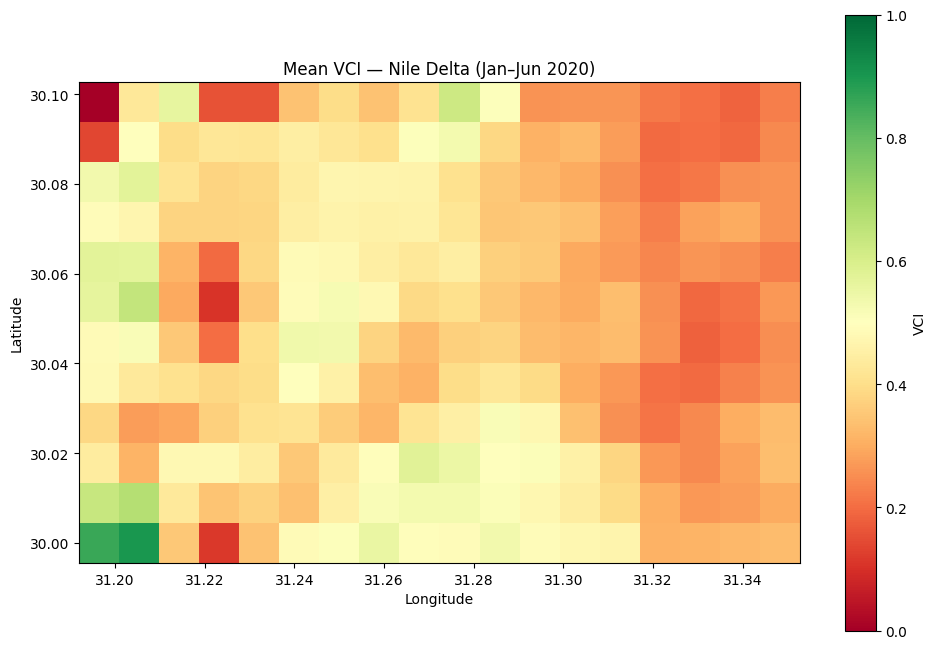

In [7]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open(output_path) as src:
    data = src.read(1)
    bounds = src.bounds

    # Mask nodata values
    if src.nodata is not None:
        data = np.where(data == src.nodata, np.nan, data)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
img = ax.imshow(
    data,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Mean VCI — Nile Delta (Jan–Jun 2020)")
plt.colorbar(img, ax=ax, label="VCI", shrink=0.8)
plt.tight_layout()
plt.show()

## 9. Submit a Batch Job

For large-area or long-running analyses, use batch jobs. The job runs asynchronously on the server and you can check its status and download results later.

In [22]:
# Create a batch job
cube = connection.load_collection(
    collection_id="VCI-D",
    spatial_extent={
        "west": 31.0,
        "east": 31.5,
        "south": 29.8,
        "north": 30.3,
    },
    temporal_extent=["2020-01-01", "2020-12-31"],
)

# Compute temporal mean
mean_cube = cube.reduce_dimension(dimension="time", reducer="mean")

# Create and start the batch job
job = mean_cube.create_job(
    out_format="GTiff",
    title="VCI Mean 2020 - Nile Delta",
)
print(f"Job created: {job.job_id}")

# Start the job
job.start_job()
print("Job started. Waiting for completion...")

Job created: j-7254041e54494967af376bbbe982a640
Job started. Waiting for completion...


In [23]:
# Check job status (run this cell periodically)
status = job.status()
print(f"Job status: {status}")

# When the job is finished, download the results
if status == "finished":
    results = job.get_results()
    results.download_files("./batch_results/")
    print("Results downloaded to ./batch_results/")

Job status: finished
Results downloaded to ./batch_results/


--- job-results.json ---
{
  "id": "j-7254041e54494967af376bbbe982a640",
  "type": "Feature",
  "stac_version": "1.0.0",
  "stac_extensions": [
    "https://stac-extensions.github.io/projection/v1.1.0/schema.json"
  ],
  "bbox": [
    30.995535719245,
    29.799107147624998,
    31.504464290755,
    30.308035719134995
  ],
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          31.504464290755,
          29.799107147624998
        ],
        [
          31.504464290755,
          30.308035719134995
        ],
        [
          30.995535719245,
          30.308035719134995
        ],
        [
          30.995535719245,
          29.799107147624998
        ],
        [
          31.504464290755,
          29.799107147624998
        ]
      ]
    ]
  },
  "properties": {
    "datetime": null,
    "proj:code": "EPSG:4326"
  },
  "assets": {
    "result.tif": {
      "href": "https://storage.googleapis.com/fao-aip-analysis-user-data/users/2aec56d2-02dc-453

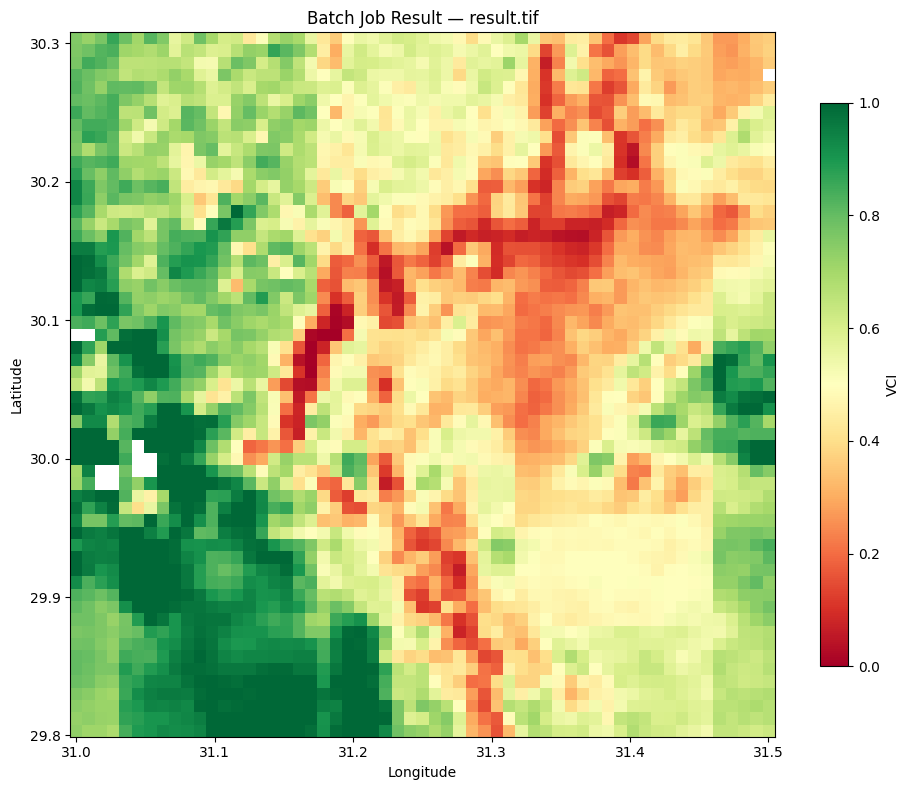

In [25]:
import os
import json as json_mod
import rasterio
import matplotlib.pyplot as plt
import numpy as np

results_dir = "./batch_results/"

for fname in sorted(os.listdir(results_dir)):
    fpath = os.path.join(results_dir, fname)

    if fname.endswith(".json"):
        with open(fpath) as f:
            data = json_mod.load(f)
        print(f"--- {fname} ---")
        print(json_mod.dumps(data, indent=2, default=str)[:2000])

    elif fname.endswith(".tif") or fname.endswith(".tiff"):
        with rasterio.open(fpath) as src:
            data = src.read(1)
            bounds = src.bounds
            if src.nodata is not None:
                data = np.where(data == src.nodata, np.nan, data)

        fig, ax = plt.subplots(figsize=(10, 8))
        img = ax.imshow(
            data,
            extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
            cmap="RdYlGn",
            vmin=0, vmax=1,
        )
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(f"Batch Job Result — {fname}")
        plt.colorbar(img, ax=ax, label="VCI", shrink=0.8)
        plt.tight_layout()
        plt.show()

    else:
        print(f"--- {fname} (skipped) ---")

## Summary

In this tutorial, you learned how to:

1. **Connect** to the FAO OpenEO backend at `https://data.fao.org/openeo`
2. **Authenticate** using basic credentials or OIDC
3. **Discover** available collections and processes
4. **Load** a data cube with spatial and temporal filters
5. **Process** data (temporal mean)
6. **Download** results in GeoTIFF or JSON format
7. **Run batch jobs** for larger analyses

### Next Steps

- **[NDVI Time Series](02_ndvi_time_series.ipynb)** — Compute and visualize vegetation indices over time
- **[Zonal Statistics](03_zonal_statistics.ipynb)** — Aggregate raster data over administrative regions
- **[Climate Risk Assessment](04_climate_risk_crtb.ipynb)** — Run CRTB hazard and vulnerability analyses
- **[Planting Recommendations](05_planting_recommendations.ipynb)** — Get agricultural planning advice with PLAN-T

You can also explore the **[OpenEO Web Editor](https://data.fao.org/editor/?server=data.fao.org%2Fopeneo)** for a visual, no-code interface to build and run process graphs.